In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Histogram of Genome Counts per Bin

In [6]:
binary = pd.read_csv('AllBiomesBinaryFinal.txt', delimiter = '\t', index_col= 0) #this is every genome, EC, and the biome it is in. Cresten Concatanated each dataframe. 
# binary.columns 
binary.head()


,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16,Biome
Name_of_Genome,,,,,,,,,,,,,,,,,,,,,
3300056625_228,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300056625_197,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,ActivatedSludge
3300055001_136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300055001_94,1,1,1,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,ActivatedSludge
3300056626_306,0,1,1,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,ActivatedSludge


In [7]:
binary.index #index is our genomes
binary['Biome'] = binary['Biome'].astype('category')
# binary.dtypes


In [8]:
sums = binary.loc[ :, binary.columns != 'Biome']
sums = sums.sum()
sums

1_1_1_1     3586
1_1_1_2     1557
1_1_1_3     4531
1_1_1_4      483
1_1_1_5        0
            ... 
7_6_2_12     138
7_6_2_13     734
7_6_2_14    1956
7_6_2_15     201
7_6_2_16     612
Length: 8269, dtype: int64

In [9]:
counts = binary['Biome'].value_counts()
counts = pd.DataFrame(counts)
counts = counts.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
counts = counts.rename(columns={'count': 'Total Genomes'})
counts = counts.reset_index()
counts

,Biome,Total Genomes
0,Bulk Soil,2267
1,Lake Sediment,2186
2,Activated Sludge,1374
3,Cow Rumen,1293
4,River Sediment,633


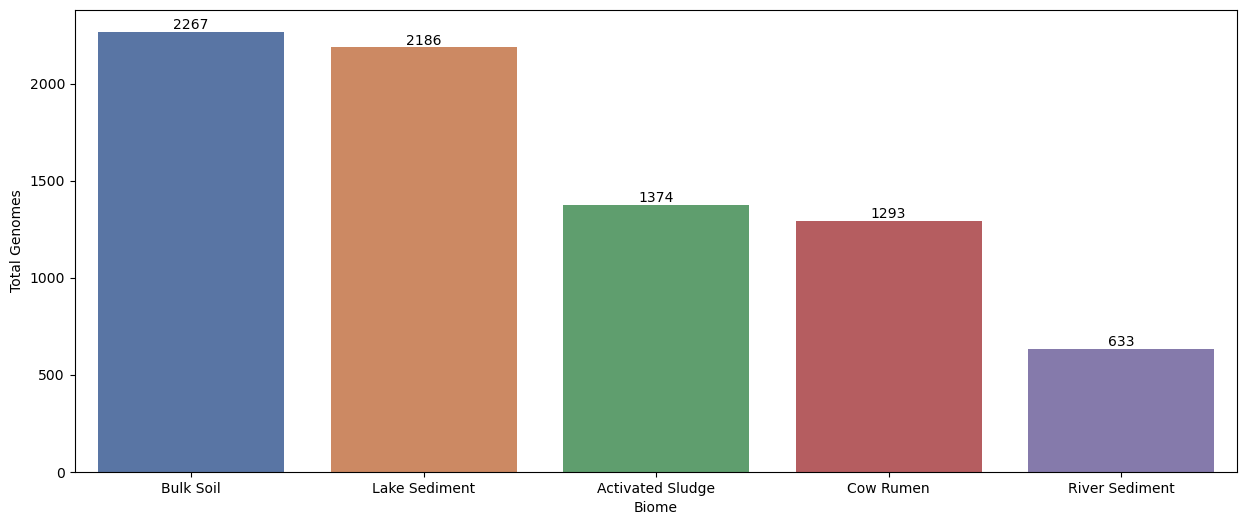

In [10]:
plt.figure(figsize=(15,6))
ax = sns.barplot(x='Biome', y='Total Genomes', data = counts, palette = 'deep')
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

In [40]:
column_sums = binary.groupby(by='Biome', observed=False).sum()
ec_sums = pd.DataFrame(column_sums)
clean = ec_sums.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
# for col in clean.columns:
#     if clean[col].sum()<=100:
#         del clean[col]
# print(ec_sums)
clean

# test = clean.loc['Activated Sludge'].sum()
# test

,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_7,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16
Biome,,,,,,,,,,,,,,,,,,,,,
Activated Sludge,411,373,751,46,0,43,0,1,86,86,...,135,171,92,306,552,57,86,270,33,130
Bulk Soil,1726,416,1564,273,0,85,0,0,271,191,...,617,367,499,775,1487,41,397,803,86,263
Cow Rumen,273,64,607,20,0,112,0,1,37,5,...,45,131,90,109,702,8,39,257,13,26
Lake Sediment,840,504,1208,84,0,114,0,0,156,25,...,175,265,145,254,822,9,168,478,42,111
River Sediment,336,200,401,60,0,28,0,0,45,25,...,84,75,107,127,349,23,44,148,27,82


In [42]:
as_sum = clean.loc['Activated Sludge'].sum()
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / as_sum) 
as_sum = clean.loc['Bulk Soil'].sum()
clean.loc['Bulk Soil'] = (clean.loc['Bulk Soil'] / as_sum) 
as_sum = clean.loc['Cow Rumen'].sum()
clean.loc['Cow Rumen'] = (clean.loc['Cow Rumen'] / as_sum) 
as_sum = clean.loc['Lake Sediment'].sum()
clean.loc['Lake Sediment'] = (clean.loc['Lake Sediment'] / as_sum) 
as_sum = clean.loc['River Sediment'].sum()
clean.loc['River Sediment'] = (clean.loc['River Sediment'] / as_sum) 
clean

,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_7,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16
Biome,,,,,,,,,,,,,,,,,,,,,
Activated Sludge,0.000600,0.000544,0.001096,0.000067,0,0.000063,0,0.000001,0.000126,0.000126,...,0.000197,0.000250,0.000134,0.000447,0.000806,0.000083,0.000126,0.000394,0.000048,0.000190
Bulk Soil,0.001260,0.000304,0.001142,0.000199,0,0.000062,0,0.000000,0.000198,0.000139,...,0.000450,0.000268,0.000364,0.000566,0.001086,0.000030,0.000290,0.000586,0.000063,0.000192
Cow Rumen,0.000552,0.000130,0.001228,0.000040,0,0.000227,0,0.000002,0.000075,0.000010,...,0.000091,0.000265,0.000182,0.000221,0.001421,0.000016,0.000079,0.000520,0.000026,0.000053
Lake Sediment,0.000899,0.000540,0.001293,0.000090,0,0.000122,0,0.000000,0.000167,0.000027,...,0.000187,0.000284,0.000155,0.000272,0.000880,0.000010,0.000180,0.000512,0.000045,0.000119
River Sediment,0.000983,0.000585,0.001174,0.000176,0,0.000082,0,0.000000,0.000132,0.000073,...,0.000246,0.000220,0.000313,0.000372,0.001021,0.000067,0.000129,0.000433,0.000079,0.000240


<Axes: ylabel='Biome'>

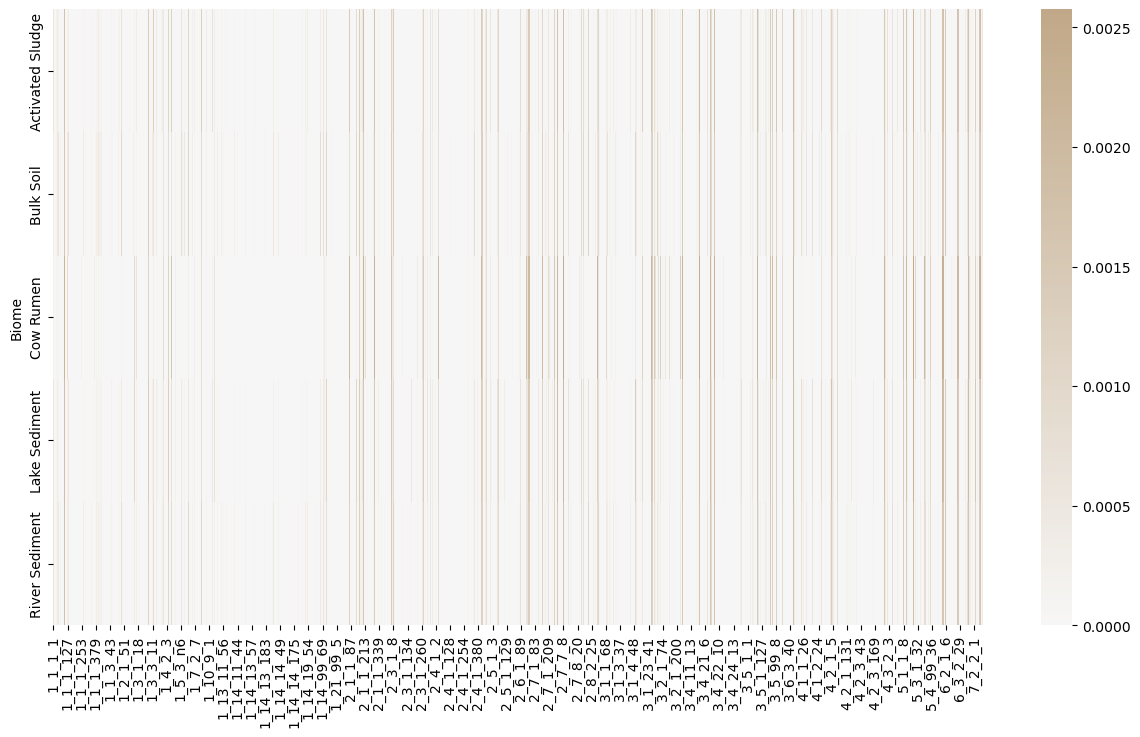

In [43]:
plt.figure(figsize=(15, 8))
color = sns.diverging_palette(220, 50, as_cmap=True)
sns.heatmap(data=clean, alpha = 0.6, center=0, cmap=color)